In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
train = pd.read_csv('/kaggle/input/datasets/faisalimam19/bikesharingdataset/train (1).csv')
test = pd.read_csv('/kaggle/input/datasets/faisalimam19/bikesharingdataset/test (1).csv')

# Basic structure
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\n")
print(train.dtypes)
print("\n")
print(train.head())
print("\n")

# Missing values
print("Missing values:\n", train.isnull().sum())

Train shape: (10886, 12)
Test shape: (6493, 9)


datetime       object
season          int64
holiday         int64
workingday      int64
weather         int64
temp          float64
atemp         float64
humidity        int64
windspeed     float64
casual          int64
registered      int64
count           int64
dtype: object


              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27    

In [2]:
# Convert datetime string to proper datetime type
train['datetime'] = pd.to_datetime(train['datetime'])
test['datetime'] = pd.to_datetime(test['datetime'])

# Extract time features
for df in [train, test]:
    df['hour']    = df['datetime'].dt.hour
    df['day']     = df['datetime'].dt.dayofweek   # 0=Monday, 6=Sunday
    df['month']   = df['datetime'].dt.month
    df['year']    = df['datetime'].dt.year

# Confirm new columns
print(train[['datetime', 'hour', 'day', 'month', 'year']].head(10))

             datetime  hour  day  month  year
0 2011-01-01 00:00:00     0    5      1  2011
1 2011-01-01 01:00:00     1    5      1  2011
2 2011-01-01 02:00:00     2    5      1  2011
3 2011-01-01 03:00:00     3    5      1  2011
4 2011-01-01 04:00:00     4    5      1  2011
5 2011-01-01 05:00:00     5    5      1  2011
6 2011-01-01 06:00:00     6    5      1  2011
7 2011-01-01 07:00:00     7    5      1  2011
8 2011-01-01 08:00:00     8    5      1  2011
9 2011-01-01 09:00:00     9    5      1  2011


In [3]:
train = train.drop(columns=['casual', 'registered'])

# Confirm
print(train.columns.tolist())
print("Train shape after drop:", train.shape)

['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'count', 'hour', 'day', 'month', 'year']
Train shape after drop: (10886, 14)


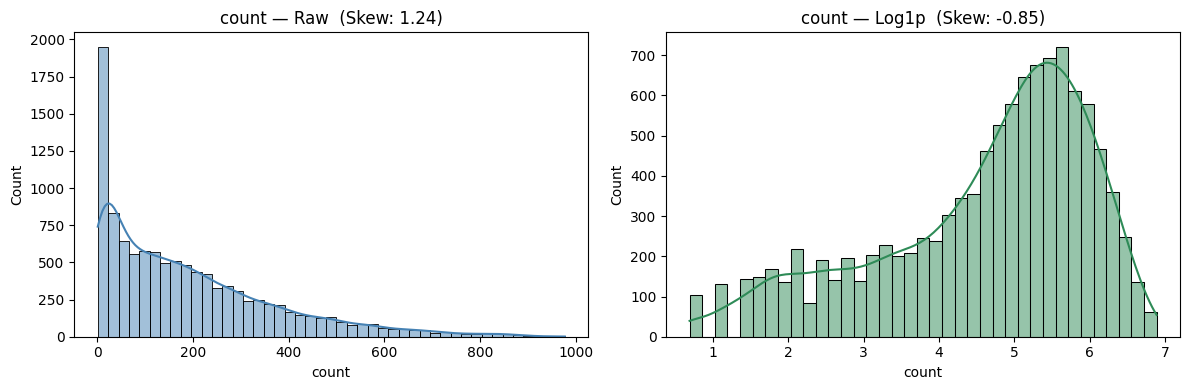

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw count
sns.histplot(train['count'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'count — Raw  (Skew: {train["count"].skew():.2f})')

# Log transformed
sns.histplot(np.log1p(train['count']), kde=True, ax=axes[1], color='seagreen')
axes[1].set_title(f'count — Log1p  (Skew: {np.log1p(train["count"]).skew():.2f})')

plt.tight_layout()
plt.show()

In [5]:
print("Raw skew:", train['count'].skew())
print("Log skew:", np.log1p(train['count']).skew())

Raw skew: 1.2420662117180776
Log skew: -0.8514116321738531


/tmp/ipykernel_16/3039112316.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='season', y='count', data=train, ax=axes[0][1], palette='Set2')
/tmp/ipykernel_16/3039112316.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0][1].set_xticklabels(['Spring', 'Summer', 'Fall', 'Winter'])
/tmp/ipykernel_16/3039112316.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='weather', y='count', data=train, ax=axes[1][0], palette='Set3')
/tmp/ipykernel_16/3039112316.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax

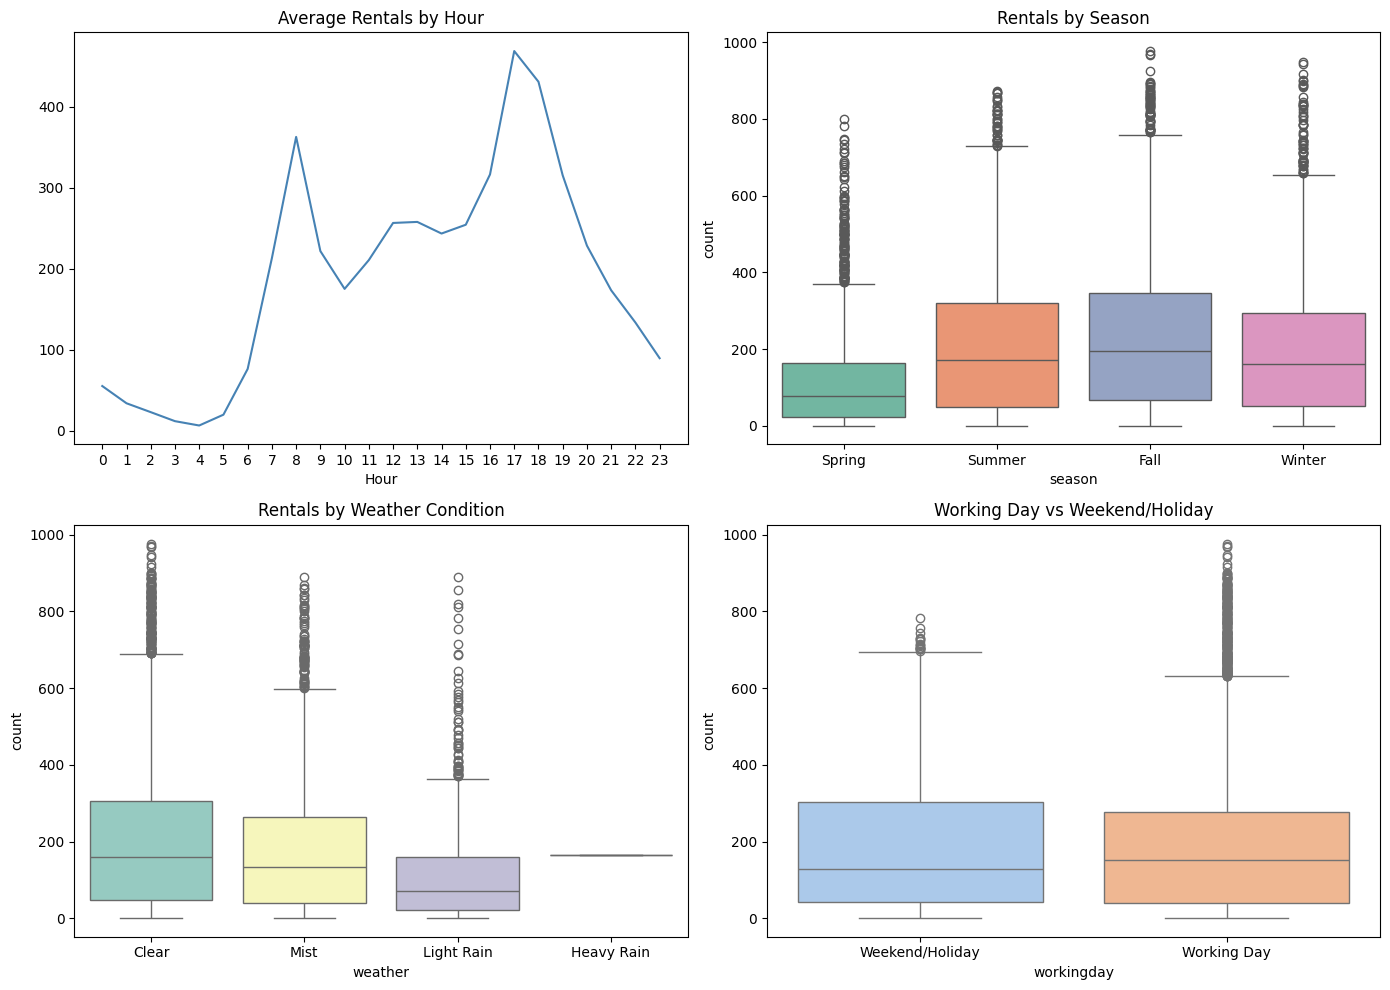

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Rentals by Hour
hourly_avg = train.groupby('hour')['count'].mean()
sns.lineplot(x=hourly_avg.index, y=hourly_avg.values, ax=axes[0][0], color='steelblue')
axes[0][0].set_title('Average Rentals by Hour')
axes[0][0].set_xlabel('Hour')
axes[0][0].set_xticks(range(0, 24))

# 2. Rentals by Season
sns.boxplot(x='season', y='count', data=train, ax=axes[0][1], palette='Set2')
axes[0][1].set_title('Rentals by Season')
axes[0][1].set_xticklabels(['Spring', 'Summer', 'Fall', 'Winter'])

# 3. Rentals by Weather
sns.boxplot(x='weather', y='count', data=train, ax=axes[1][0], palette='Set3')
axes[1][0].set_title('Rentals by Weather Condition')
axes[1][0].set_xticklabels(['Clear', 'Mist', 'Light Rain', 'Heavy Rain'])

# 4. Workingday vs Weekend
sns.boxplot(x='workingday', y='count', data=train, ax=axes[1][1], palette='pastel')
axes[1][1].set_title('Working Day vs Weekend/Holiday')
axes[1][1].set_xticklabels(['Weekend/Holiday', 'Working Day'])

plt.tight_layout()
plt.show()

In [7]:
for df in [train, test]:

    # 1. Rush hour flag
    # Your plot showed peaks at 8 and 17
    # Working day commute hours are meaningfully different from all other hours
    df['is_rush_hour'] = df['hour'].apply(
        lambda x: 1 if x in [8, 17, 18] else 0
    )

    # 2. Time of day buckets
    # Grouping hours into meaningful periods instead of 24 raw numbers
    # Night / Morning / Afternoon / Evening
    def time_of_day(hour):
        if 0 <= hour < 6:
            return 0   # Night — very low demand
        elif 6 <= hour < 12:
            return 1   # Morning — includes rush hour
        elif 12 <= hour < 18:
            return 2   # Afternoon — steady demand
        else:
            return 3   # Evening — second peak + wind down

    df['time_of_day'] = df['hour'].apply(time_of_day)

    # 3. Workingday + Rush Hour interaction
    # A working day at 8 AM is fundamentally different from
    # a weekend at 8 AM — this feature captures that combination
    df['workday_rush'] = df['workingday'] * df['is_rush_hour']

# Verify
print(train[['hour', 'workingday', 'is_rush_hour', 'time_of_day', 'workday_rush']].head(20))
print("\nNew train shape:", train.shape)

    hour  workingday  is_rush_hour  time_of_day  workday_rush
0      0           0             0            0             0
1      1           0             0            0             0
2      2           0             0            0             0
3      3           0             0            0             0
4      4           0             0            0             0
5      5           0             0            0             0
6      6           0             0            1             0
7      7           0             0            1             0
8      8           0             1            1             0
9      9           0             0            1             0
10    10           0             0            1             0
11    11           0             0            1             0
12    12           0             0            2             0
13    13           0             0            2             0
14    14           0             0            2             0
15    15

In [8]:
# Apply log transform to target
train['count_log'] = np.log1p(train['count'])

# Define features — same columns must exist in both train and test
features = [
    'season', 'holiday', 'workingday', 'weather',
    'temp', 'atemp', 'humidity', 'windspeed',
    'hour', 'day', 'month', 'year',
    'is_rush_hour', 'time_of_day', 'workday_rush'
]

X = train[features]
y = train['count_log']
X_test = test[features]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("X_test shape:", X_test.shape)
print("\nFeatures used:", features)

X shape: (10886, 15)
y shape: (10886,)
X_test shape: (6493, 15)

Features used: ['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'hour', 'day', 'month', 'year', 'is_rush_hour', 'time_of_day', 'workday_rush']


In [9]:
# Check the actual values
print(train[['hour', 'workingday', 'is_rush_hour', 'workday_rush']].head(30))

# Also check unique values in workingday
print("\nUnique workingday values:", train['workingday'].unique())
print("Unique is_rush_hour values:", train['is_rush_hour'].unique())
print("Unique workday_rush values:", train['workday_rush'].unique())

    hour  workingday  is_rush_hour  workday_rush
0      0           0             0             0
1      1           0             0             0
2      2           0             0             0
3      3           0             0             0
4      4           0             0             0
5      5           0             0             0
6      6           0             0             0
7      7           0             0             0
8      8           0             1             0
9      9           0             0             0
10    10           0             0             0
11    11           0             0             0
12    12           0             0             0
13    13           0             0             0
14    14           0             0             0
15    15           0             0             0
16    16           0             0             0
17    17           0             1             0
18    18           0             1             0
19    19           0

In [10]:
print("workingday unique:", train['workingday'].unique())
print("is_rush_hour unique:", train['is_rush_hour'].unique())

# Also check how many rush hours exist
print("\nRush hour count:", train['is_rush_hour'].sum())

# And check a few rows around hour 8
print("\nRows where hour=8:")
print(train[train['hour'] == 8][['hour', 'workingday', 'is_rush_hour', 'workday_rush']].head(5))

workingday unique: [0 1]
is_rush_hour unique: [0 1]

Rush hour count: 1367

Rows where hour=8:
    hour  workingday  is_rush_hour  workday_rush
8      8           0             1             0
31     8           0             1             0
53     8           1             1             1
76     8           1             1             1
99     8           1             1             1


In [11]:
# Re-run this to recalculate workday_rush with correct values
train['workday_rush'] = train['workingday'] * train['is_rush_hour']
test['workday_rush'] = test['workingday'] * test['is_rush_hour']

# Verify now
print(train[['hour', 'workingday', 'is_rush_hour', 'workday_rush']].head(30))
print("\nworkday_rush unique values:", train['workday_rush'].unique())
print("workday_rush = 1 count:", train['workday_rush'].sum())

    hour  workingday  is_rush_hour  workday_rush
0      0           0             0             0
1      1           0             0             0
2      2           0             0             0
3      3           0             0             0
4      4           0             0             0
5      5           0             0             0
6      6           0             0             0
7      7           0             0             0
8      8           0             1             0
9      9           0             0             0
10    10           0             0             0
11    11           0             0             0
12    12           0             0             0
13    13           0             0             0
14    14           0             0             0
15    15           0             0             0
16    16           0             0             0
17    17           0             1             0
18    18           0             1             0
19    19           0

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# Split data — 80% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

# Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict on validation set
y_pred = lr.predict(X_val)

# Evaluate using RMSLE
# Since y is already log transformed, RMSE of log = RMSLE
rmsle = np.sqrt(mean_squared_error(y_val, y_pred))
print("\nLinear Regression RMSLE:", round(rmsle, 4))

X_train shape: (8708, 15)
X_val shape: (2178, 15)

Linear Regression RMSLE: 0.9293


In [13]:
# Feature weights
coefficients = pd.DataFrame({
    'Feature': features,
    'Weight': lr.coef_
}).sort_values('Weight', ascending=False)

print(coefficients)

         Feature    Weight
14  workday_rush  1.093256
13   time_of_day  1.016470
11          year  0.439658
12  is_rush_hour  0.206865
10         month  0.070530
5          atemp  0.038054
9            day  0.022639
1        holiday  0.017418
7      windspeed  0.002044
4           temp  0.001480
6       humidity -0.012674
0         season -0.036759
3        weather -0.039555
8           hour -0.065495
2     workingday -0.137445


In [14]:
from sklearn.linear_model import Ridge

# Train Ridge
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

# Predict and evaluate
y_pred_ridge = ridge.predict(X_val)
rmsle_ridge = np.sqrt(mean_squared_error(y_val, y_pred_ridge))
print("Ridge RMSLE:", round(rmsle_ridge, 4))

# Compare weights vs Linear Regression
coef_comparison = pd.DataFrame({
    'Feature': features,
    'Linear': lr.coef_,
    'Ridge': ridge.coef_
}).sort_values('Linear', ascending=False)

print("\nWeight Comparison:")
print(coef_comparison)

Ridge RMSLE: 0.9293

Weight Comparison:
         Feature    Linear     Ridge
14  workday_rush  1.093256  1.088761
13   time_of_day  1.016470  1.014927
11          year  0.439658  0.439450
12  is_rush_hour  0.206865  0.209773
10         month  0.070530  0.070505
5          atemp  0.038054  0.038060
9            day  0.022639  0.022671
1        holiday  0.017418  0.017547
7      windspeed  0.002044  0.002045
4           temp  0.001480  0.001476
6       humidity -0.012674 -0.012676
0         season -0.036759 -0.036678
3        weather -0.039555 -0.039522
8           hour -0.065495 -0.065255
2     workingday -0.137445 -0.136673


In [15]:
from sklearn.linear_model import Lasso

# Train Lasso
lasso = Lasso(alpha=0.01)  # Lower alpha than Ridge — Lasso is more aggressive
lasso.fit(X_train, y_train)

# Predict and evaluate
y_pred_lasso = lasso.predict(X_val)
rmsle_lasso = np.sqrt(mean_squared_error(y_val, y_pred_lasso))
print("Lasso RMSLE:", round(rmsle_lasso, 4))

# Check which features Lasso eliminated
lasso_coefs = pd.DataFrame({
    'Feature': features,
    'Lasso Weight': lasso.coef_
}).sort_values('Lasso Weight', ascending=False)

print("\nLasso Weights (zeros = eliminated):")
print(lasso_coefs)
print("\nFeatures eliminated by Lasso:", 
      lasso_coefs[lasso_coefs['Lasso Weight'] == 0]['Feature'].tolist())

Lasso RMSLE: 0.9301

Lasso Weights (zeros = eliminated):
         Feature  Lasso Weight
14  workday_rush      0.909058
13   time_of_day      0.869478
11          year      0.398735
12  is_rush_hour      0.247426
10         month      0.058465
5          atemp      0.038671
9            day      0.032118
7      windspeed      0.001679
4           temp      0.001090
0         season      0.000000
1        holiday      0.000000
3        weather     -0.006672
6       humidity     -0.013366
2     workingday     -0.041356
8           hour     -0.042166

Features eliminated by Lasso: ['season', 'holiday']


In [16]:
print("=" * 40)
print("MODEL COMPARISON")
print("=" * 40)
print(f"Linear Regression RMSLE : {rmsle:.4f}")
print(f"Ridge Regression RMSLE  : {rmsle_ridge:.4f}")
print(f"Lasso Regression RMSLE  : {rmsle_lasso:.4f}")
print("=" * 40)

MODEL COMPARISON
Linear Regression RMSLE : 0.9293
Ridge Regression RMSLE  : 0.9293
Lasso Regression RMSLE  : 0.9301


In [17]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=500,      # Number of trees
    learning_rate=0.05,    # How much each tree contributes
    max_depth=6,           # How deep each tree grows
    random_state=42,
    n_jobs=-1              # Use all CPU cores
)

xgb.fit(X_train, y_train)

# Predict and evaluate
y_pred_xgb = xgb.predict(X_val)
rmsle_xgb = np.sqrt(mean_squared_error(y_val, y_pred_xgb))
print("XGBoost RMSLE:", round(rmsle_xgb, 4))

XGBoost RMSLE: 0.2882


In [18]:
print("=" * 40)
print("FINAL MODEL COMPARISON")
print("=" * 40)
print(f"Linear Regression : {rmsle:.4f}")
print(f"Ridge             : {rmsle_ridge:.4f}")
print(f"Lasso             : {rmsle_lasso:.4f}")
print(f"XGBoost           : {rmsle_xgb:.4f}")
print("=" * 40)

FINAL MODEL COMPARISON
Linear Regression : 0.9293
Ridge             : 0.9293
Lasso             : 0.9301
XGBoost           : 0.2882


         Feature  Importance
14  workday_rush    0.323398
8           hour    0.288544
11          year    0.105359
2     workingday    0.094231
0         season    0.042760
4           temp    0.029362
9            day    0.029010
10         month    0.027320
3        weather    0.018879
5          atemp    0.016780
6       humidity    0.010202
1        holiday    0.005528
12  is_rush_hour    0.005471
7      windspeed    0.003156
13   time_of_day    0.000000


/tmp/ipykernel_16/2170382256.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')


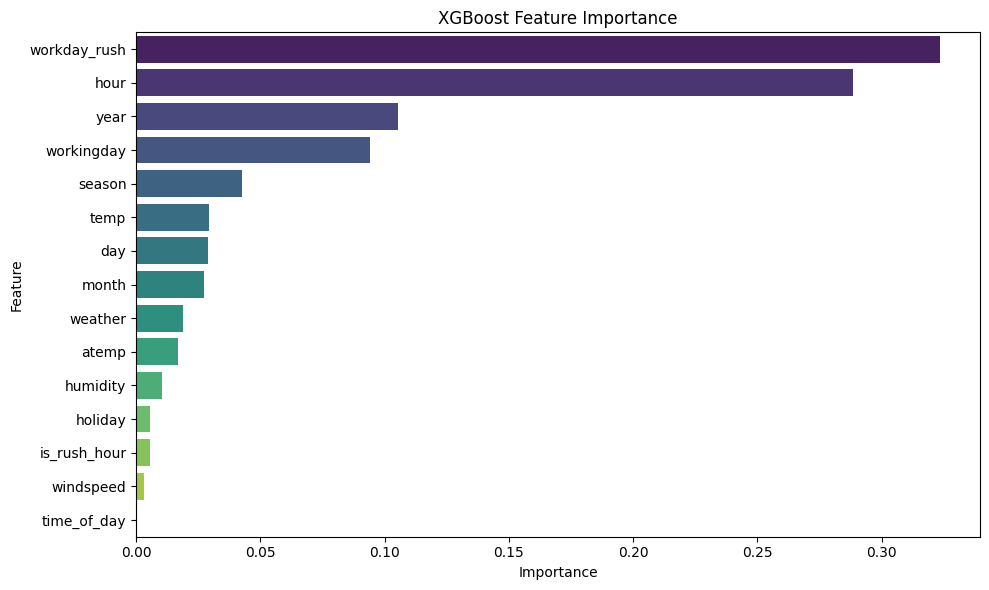

In [19]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

# Visual
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

In [20]:
# Predict on test set
test_pred_log = xgb.predict(X_test)

# Reverse the log transform
test_pred = np.expm1(test_pred_log)

# Clip negatives — rentals can't be negative
test_pred = np.clip(test_pred, 0, None)

# Build submission file
submission = pd.DataFrame({
    'datetime': test['datetime'],
    'count': test_pred
})

submission.to_csv('submission.csv', index=False)
print("Submission saved!")
print(submission.head(10))

Submission saved!
             datetime       count
0 2011-01-20 00:00:00   10.875971
1 2011-01-20 01:00:00    4.353595
2 2011-01-20 02:00:00    3.300838
3 2011-01-20 03:00:00    1.973829
4 2011-01-20 04:00:00    1.615596
5 2011-01-20 05:00:00    5.603158
6 2011-01-20 06:00:00   34.029331
7 2011-01-20 07:00:00   98.200371
8 2011-01-20 08:00:00  217.436035
9 2011-01-20 09:00:00  101.360161


In [21]:
# Reload fresh train data
train = pd.read_csv('/kaggle/input/datasets/faisalimam19/bikesharingdataset/train (1).csv')
test = pd.read_csv('/kaggle/input/datasets/faisalimam19/bikesharingdataset/test (1).csv')

# Re-apply all our feature engineering
for df in [train, test]:
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['hour']     = df['datetime'].dt.hour
    df['day']      = df['datetime'].dt.dayofweek
    df['month']    = df['datetime'].dt.month
    df['year']     = df['datetime'].dt.year
    
    df['is_rush_hour'] = df['hour'].apply(lambda x: 1 if x in [8, 17, 18] else 0)
    
    def time_of_day(hour):
        if 0 <= hour < 6:    return 0
        elif 6 <= hour < 12: return 1
        elif 12 <= hour < 18: return 2
        else:                 return 3
    
    df['time_of_day']  = df['hour'].apply(time_of_day)
    df['workday_rush'] = df['workingday'] * df['is_rush_hour']

print("Data reloaded and features engineered ✅")
print(train.columns.tolist())

Data reloaded and features engineered ✅
['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count', 'hour', 'day', 'month', 'year', 'is_rush_hour', 'time_of_day', 'workday_rush']


In [22]:
for df in [train, test]:
    # 1. Temp bins — rentals don't grow linearly with temp
    # Too cold = low, ideal = high, too hot = drops
    df['temp_bin'] = pd.cut(
        df['temp'],
        bins=[0, 10, 20, 30, 50],
        labels=[0, 1, 2, 3]
    ).astype(int)

    # 2. Weekend flag — cleaner than day of week
    df['is_weekend'] = (df['day'] >= 5).astype(int)

print("New features added ✅")

New features added ✅


In [23]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

features = [
    'season', 'holiday', 'workingday', 'weather',
    'temp', 'atemp', 'humidity', 'windspeed',
    'hour', 'day', 'month', 'year',
    'is_rush_hour', 'time_of_day', 'workday_rush',
    'temp_bin', 'is_weekend'
]

X      = train[features]
X_test = test[features]

# Log transform all three targets
y_casual     = np.log1p(train['casual'])
y_registered = np.log1p(train['registered'])
y_count      = np.log1p(train['count'])

# Split
X_train, X_val, y_cas_train, y_cas_val = train_test_split(
    X, y_casual, test_size=0.2, random_state=42
)
_, _, y_reg_train, y_reg_val = train_test_split(
    X, y_registered, test_size=0.2, random_state=42
)
_, _, y_cnt_train, y_cnt_val = train_test_split(
    X, y_count, test_size=0.2, random_state=42
)

# Tuned XGBoost params
params = {
    'n_estimators'  : 1000,
    'learning_rate' : 0.05,
    'max_depth'     : 6,
    'subsample'     : 0.8,       # Use 80% of rows per tree
    'colsample_bytree': 0.8,     # Use 80% of features per tree
    'min_child_weight': 3,       # Prevent overfitting on small groups
    'random_state'  : 42,
    'n_jobs'        : -1
}

# Train casual model
xgb_casual = XGBRegressor(**params)
xgb_casual.fit(X_train, y_cas_train)

# Train registered model
xgb_registered = XGBRegressor(**params)
xgb_registered.fit(X_train, y_reg_train)

# Validate — sum casual + registered predictions
cas_pred = xgb_casual.predict(X_val)
reg_pred = xgb_registered.predict(X_val)

# Convert back from log and sum
combined_pred = np.log1p(np.expm1(cas_pred) + np.expm1(reg_pred))
rmsle_combined = np.sqrt(mean_squared_error(y_cnt_val, combined_pred))

print("=" * 40)
print("IMPROVED MODEL RESULTS")
print("=" * 40)
print(f"Previous XGBoost RMSLE  : 0.2882")
print(f"Improved XGBoost RMSLE  : {rmsle_combined:.4f}")
print("=" * 40)

IMPROVED MODEL RESULTS
Previous XGBoost RMSLE  : 0.2882
Improved XGBoost RMSLE  : 0.2765


In [24]:
# Predict on test
cas_test  = np.expm1(xgb_casual.predict(X_test))
reg_test  = np.expm1(xgb_registered.predict(X_test))

# Sum and clip
final_pred = np.clip(cas_test + reg_test, 0, None)

submission = pd.DataFrame({
    'datetime': test['datetime'],
    'count'   : final_pred
})

submission.to_csv('/kaggle/working/submission.csv', index=False)
print("New submission saved ✅")
print(submission.head(10))

New submission saved ✅
             datetime       count
0 2011-01-20 00:00:00   12.426415
1 2011-01-20 01:00:00    4.117987
2 2011-01-20 02:00:00    2.603194
3 2011-01-20 03:00:00    1.515286
4 2011-01-20 04:00:00    1.092120
5 2011-01-20 05:00:00    5.835074
6 2011-01-20 06:00:00   34.815639
7 2011-01-20 07:00:00   98.384857
8 2011-01-20 08:00:00  214.820923
9 2011-01-20 09:00:00  107.880363


In [25]:
print(f"New validation RMSLE: {rmsle_combined:.4f}")

New validation RMSLE: 0.2765
